<a href="https://colab.research.google.com/github/vishnuvardhan1699/2520030392_ML/blob/main/Skill/week_3_housing_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iteration    0 | Loss: 28148711615.5157
Iteration  100 | Loss: 6455984966.9323
Iteration  200 | Loss: 3426756289.6654
Iteration  300 | Loss: 2946806834.3682
Iteration  400 | Loss: 2827464270.8854
Iteration  500 | Loss: 2766274502.3543
Iteration  600 | Loss: 2719783618.2102
Iteration  700 | Loss: 2680827537.2339
Iteration  800 | Loss: 2647558344.6216
Iteration  900 | Loss: 2619027995.6156

Final weights (theta):
[207185.74888449 -42866.7912928  -48179.61199926  20106.34814799
 -28941.43206935  35903.79696059  77871.63258691]

Test MSE : 5299178797.4392
Test R^2 : 0.5956

Scikit-learn Results
MSE : 4974547488.0342
R^2 : 0.6204

Scikit-learn Linear Regression R²: 0.6204
Plot saved as housing_gradient_descent.png


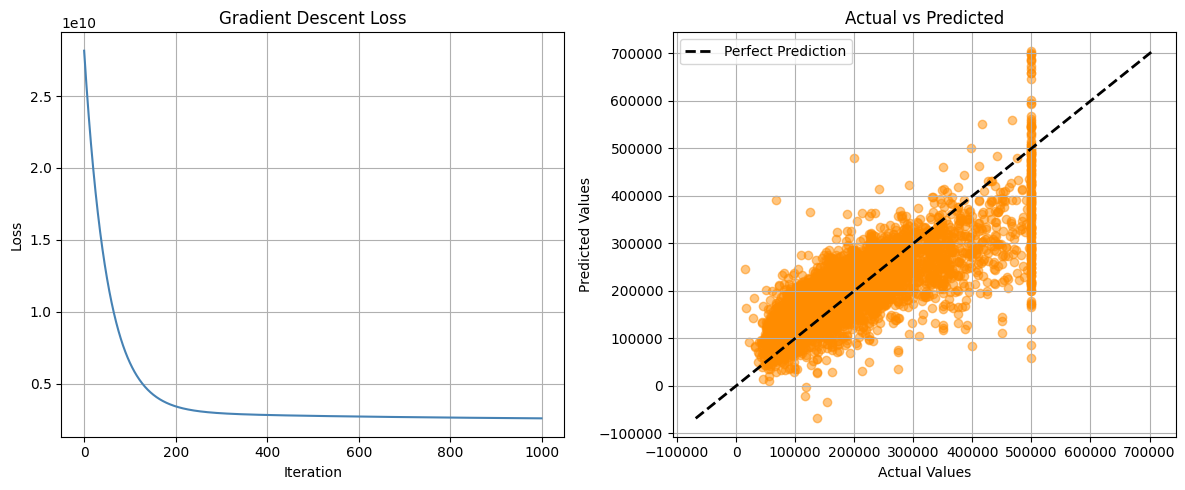

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

df = pd.read_csv("/content/housing.csv")

target_col = "median_house_value"

drop_cols = [target_col, "total_bedrooms", "total_rooms"]
feature_df = df.drop(columns=drop_cols).select_dtypes(include=[np.number])

feature_df = feature_df.fillna(feature_df.median())

X = feature_df.values
y = df[target_col].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for i in range(n_iters):
        y_pred = X @ theta
        error = y_pred - y

        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)

        gradient = (1 / m) * (X.T @ error)

        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    return theta, losses

theta, losses = gradient_descent(
    X_train_b, y_train, lr=0.01, n_iters=1000
)

y_pred = X_test_b @ theta

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())

print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print("\nScikit-learn Results")
print(f"MSE : {mean_squared_error(y_test, sk_pred):.4f}")
print(f"R^2 : {r2_score(y_test, sk_pred):.4f}")

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print(f"\nScikit-learn Linear Regression R²: {r2_score(y_test, sk_pred):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(losses, color="steelblue")
axes[0].set_title("Gradient Descent Loss")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].scatter(y_test, y_pred, color="darkorange", alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    "k--",
    linewidth=2,
    label="Perfect Prediction"
)

axes[1].set_title("Actual vs Predicted")
axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Predicted Values")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("housing_gradient_descent.png", dpi=150)
print("Plot saved as housing_gradient_descent.png")
plt.show()